<a href="https://colab.research.google.com/github/ShamimtheAnalyst/Crash-Course/blob/main/Two_Way_ANOVA_in_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Statistical Modeling: Two-Way ANOVA & Interaction Effects

### নোটবুক পরিচিতি (Metadata)

* **Aim:** `ToothGrowth` ডাটাসেট ব্যবহার করে দেখা যে, দাঁতের বৃদ্ধির ওপর ভিটামিন সাপ্লিমেন্ট (`supp`) এবং ডোজের পরিমাণ (`dose`) একত্রে কীভাবে প্রভাব ফেলে।
* **Concept:** One-Way ANOVA শুধু একটি ফ্যাক্টর দেখে, কিন্তু **Two-Way ANOVA** ফ্যাক্টরগুলোর মধ্যকার "ইন্টারঅ্যাকশন" (Interaction) খুঁজে বের করে।
* **Key Skills:** Interaction Modeling (`supp * dose`), Tukey HSD, Multi-group Lettering, এবং Google Font Integration।

---

## কেন Two-Way ANOVA এবং ইন্টারঅ্যাকশন ইফেক্ট গুরুত্বপূর্ণ?

১. **যৌথ প্রভাব:** অনেক সময় একটি ফ্যাক্টরের প্রভাব অন্যটির ওপর নির্ভর করে। যেমন: কম ডোজে হয়তো Orange Juice (OJ) ভালো কাজ করে, কিন্তু বেশি ডোজে Vitamin C (VC) ভালো হতে পারে।
২. **সূক্ষ্ম বিশ্লেষণ:** এটি আমাদের জানায় যে সাপ্লিমেন্ট এবং ডোজের কোন কম্বিনেশনটি সবচেয়ে কার্যকর।
৩. **প্রকাশনাযোগ্য গ্রাফ:** CLD লেটারিং ব্যবহারের ফলে রিডাররা সহজেই বুঝতে পারেন কোন দুটি বারের মধ্যে পরিসংখ্যানগত পার্থক্য আছে।

---

## ১. এনভায়রনমেন্ট ও ফন্ট সেটআপ (Environment Setup)

প্রফেশনাল লুকের জন্য আমরা গুগল ফন্ট "Poppins" ব্যবহার করব।

In [14]:
install.packages('ggthemes')
install.packages('multcompView')
install.packages('stats')
install.packages('showtext')


library(tidyverse)
library(ggthemes)
library(multcompView)
library(stats)
library(showtext)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message:
“package ‘stats’ is a base package, and should not be updated”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [15]:
# গুগল ফন্ট "Poppins" সক্রিয় করা
font_add_google("Poppins", "poppins")
showtext_auto()

# ডিফল্ট থিম সেটআপ
theme_set(theme_test(base_size = 15) +
            theme(text = element_text(family = "poppins")))


In [16]:
# ডাটাসেট লোড ও ডোজকে ফ্যাক্টরে রূপান্তর
df <- ToothGrowth
df$dose <- as.factor(df$dose)

## ২. টু-ওয়ে ANOVA ও পোস্ট-হক বিশ্লেষণ (The Analysis)

### ধাপ ১: ANOVA ক্যালকুলেশন

এখানে আমরা `supp * dose` ব্যবহার করছি যেন তাদের মধ্যকার ইন্টারঅ্যাকশন বোঝা যায়।

In [17]:
# ANOVA রান করা
anova_result <- aov(len ~ supp * dose, data = df)
summary(anova_result)


            Df Sum Sq Mean Sq F value   Pr(>F)    
supp         1  205.4   205.4  15.572 0.000231 ***
dose         2 2426.4  1213.2  92.000  < 2e-16 ***
supp:dose    2  108.3    54.2   4.107 0.021860 *  
Residuals   54  712.1    13.2                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

### ধাপ ২: মাল্টিপল কম্পারিজন (Tukey Test)

ইন্টারঅ্যাকশন সিগনিফিকেন্ট হলে আমরা দেখি কোন পেয়ারগুলো আলাদা।


In [18]:
# Tukey Test এবং লেটারিং এক্সট্রাক্ট করা
tukey_result <- TukeyHSD(anova_result)
group_lettering <- multcompLetters4(anova_result, tukey_result)


In [19]:
# লেটারগুলোকে ডেটাফ্রেমে সাজানো
group_lettering2 <- data.frame(group_lettering$`supp:dose`$Letters)

## ৩. ডেটা প্রসেসিং ও লেটারিং ইন্টিগ্রেশন

গ্রাফে প্লট করার জন্য গড় এবং স্ট্যান্ডার্ড ডেভিয়েশন বের করে তার সাথে CLD লেটারগুলো যুক্ত করি।


In [20]:
df1 <- df %>%
  group_by(supp, dose) %>%
  summarise(len_mean = mean(len),
            sd = sd(len), .groups = 'drop') %>%
  arrange(desc(len_mean))

In [21]:
# লেটারগুলো মেইন সামারি ডেটায় যোগ করা
df1$group_lettering <- group_lettering2$group_lettering..supp.dose..Letters


## ৪. পাবলিকেশন রেডি ভিজ্যুয়ালাইজেশন (Final Plot)

এখন আমরা একটি এরর বারসহ প্রফেশনাল বারপ্লট তৈরি করব।


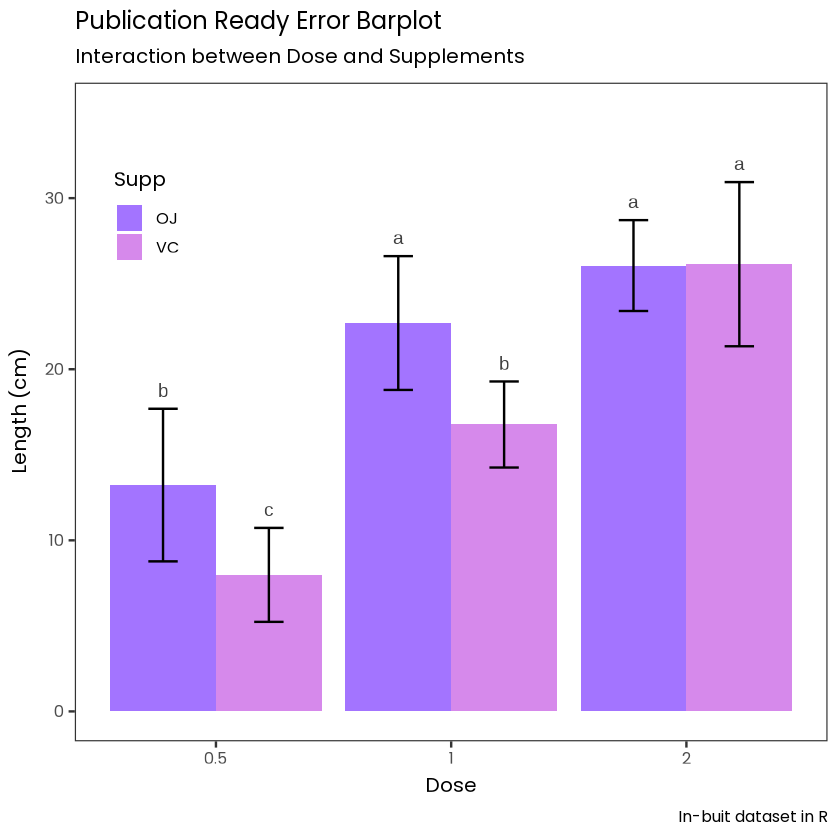

In [22]:
df1 %>%
  ggplot(aes(dose, len_mean, group = supp)) +
  geom_bar(position = position_dodge(0.9), stat = "identity",
           aes(fill = supp), alpha = 0.8) + # Alpha কিছুটা বাড়ানো হয়েছে ভিজিবিলিটির জন্য
  geom_errorbar(aes(ymin = len_mean - sd, ymax = len_mean + sd),
                width = 0.25, position = position_dodge(0.9)) +
  # CLD লেটার যোগ করা
  geom_text(aes(label = group_lettering, y = len_mean + sd),
            vjust = -0.9, color = "gray25",
            position = position_dodge(0.9), size = 5) +
  scale_fill_manual(values = c("OJ" = "#8c52ff", "VC" = "#cb6ce6")) +
  labs(x = "Dose", y = "Length (cm)",
       title = "Publication Ready Error Barplot",
       subtitle = "Interaction between Dose and Supplements",
       caption = "In-buit dataset in R", fill = "Supp") +
  ylim(0, 35) +
  theme(panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        legend.position = c(0.1, 0.80))

---

## এক নজরে আপনার শেখা টুলকিট (Cheat Sheet):

* **`aov(len ~ A * B)`**: দুটি ফ্যাক্টরের মেইন ইফেক্ট এবং তাদের ইন্টারঅ্যাকশন পরীক্ষা করে।
* **`showtext_auto()`**: R গ্রাফিক্সে কাস্টম টাইপোগ্রাফি বা গুগল ফন্ট ব্যবহারের অনুমতি দেয়।
* **`position_dodge()`**: বারগুলোকে একে অপরের পাশে সুন্দরভাবে সাজাতে সাহায্য করে।
* **`multcompLetters4()`**: জটিল ইন্টারঅ্যাকশন রেজাল্টকে সহজবোধ্য লেটারে রূপান্তর করে।

---

